---
## Validation par sujet : Test du data leakage

**Problème potentiel :** Le split aléatoire peut mettre des segments du même sujet en train ET en test.  
Un sujet en apnée sévère (96% de ses minutes = apnée) peut "contaminer" le test set avec son profil individuel.  
C'est du **subject leakage** — fréquent en biosignaux.

**Solution :** Split par sujet — le test set contient des sujets **entiers jamais vus** à l'entraînement.

In [3]:
import numpy as np
import wfdb
from pathlib import Path
from scipy.signal import find_peaks, welch
from scipy import stats

DATA_RAW_ECG = Path('../data/raw_apnea')
FS_ECG = 100
SEG_SAMPLES = 6000

print('=== VALIDATION PAR SUJET — ECG ===')
print('Train : a01, a02, a03, a05, b01, c01, c02')
print('Test  : a04 (❌ corrompu), b02, c03 → sujets jamais vus')
print()

# Réutiliser les fonctions du notebook
def extract_rr_intervals(ecg_segment, fs=100):
    ecg_norm = (ecg_segment - np.mean(ecg_segment)) / (np.std(ecg_segment) + 1e-8)
    peaks, _ = find_peaks(ecg_norm, height=0.5, distance=int(0.3 * fs))
    if len(peaks) < 2:
        return np.array([]), peaks
    rr = np.diff(peaks) / fs
    return rr[(rr > 0.3) & (rr < 2.0)], peaks

def extract_ecg_features(ecg_segment, fs=100):
    features = []
    features.append(np.mean(ecg_segment))
    features.append(np.std(ecg_segment))
    features.append(np.min(ecg_segment))
    features.append(np.max(ecg_segment))
    features.append(np.max(ecg_segment) - np.min(ecg_segment))
    rr, peaks = extract_rr_intervals(ecg_segment, fs)
    if len(rr) >= 2:
        features.extend([np.mean(rr), np.std(rr), np.min(rr),
                          np.max(rr), np.sqrt(np.mean(np.diff(rr)**2))])
    else:
        features.extend([0.8, 0.05, 0.6, 1.2, 0.05])
    if len(rr) >= 4:
        rr_times = np.cumsum(rr)
        t_uniform = np.arange(0, rr_times[-1], 0.25)
        rr_uniform = np.interp(t_uniform, rr_times, rr)
        if len(rr_uniform) > 8:
            freqs_hrv, psd_hrv = welch(rr_uniform, fs=4,
                                        nperseg=min(len(rr_uniform), 64))
            lf = np.sum(psd_hrv[(freqs_hrv>=0.04)&(freqs_hrv<0.15)])
            hf = np.sum(psd_hrv[(freqs_hrv>=0.15)&(freqs_hrv<0.40)])
            features.extend([lf, hf, lf/(hf+1e-8)])
        else:
            features.extend([0, 0, 1])
    else:
        features.extend([0, 0, 1])
    if len(peaks) > 0:
        amp = ecg_segment[peaks]
        features.extend([np.mean(amp), np.std(amp),
                          len(peaks)/(len(ecg_segment)/fs/60)])
    else:
        features.extend([0, 0, 60])
    return np.array(features[:16], dtype=np.float32)

def load_subject_features(subj_id, data_dir):
    rec = wfdb.rdrecord(str(data_dir / subj_id))
    ann = wfdb.rdann(str(data_dir / subj_id), 'apn')
    ecg = rec.p_signal[:, 0]
    segments, labels = [], []
    for i, sym in enumerate(ann.symbol):
        if sym not in ['A', 'N']:
            continue
        start = i * SEG_SAMPLES
        end   = start + SEG_SAMPLES
        if end <= len(ecg):
            segments.append(extract_ecg_features(ecg[start:end]))
            labels.append(1 if sym == 'A' else 0)
    return np.array(segments), np.array(labels)

print('Fonctions prêtes')

=== VALIDATION PAR SUJET — ECG ===
Train : a01, a02, a03, a05, b01, c01, c02
Test  : a04 (❌ corrompu), b02, c03 → sujets jamais vus

Fonctions prêtes


In [4]:
# Split par sujet
TRAIN_SUBJECTS = ['a01', 'a02', 'a03', 'a05', 'b01', 'c01', 'c02']
TEST_SUBJECTS  = ['b02', 'c03']  # a04 corrompu → exclu

# Charger train
X_train_subj, y_train_subj = [], []
for subj in TRAIN_SUBJECTS:
    try:
        X_s, y_s = load_subject_features(subj, DATA_RAW_ECG)
        X_train_subj.append(X_s)
        y_train_subj.append(y_s)
        print(f'   Train {subj} : {len(y_s)} segments | '
              f'Apnée={sum(y_s==1)} Normal={sum(y_s==0)}')
    except Exception as e:
        print(f'   {subj} ❌ {e}')

# Charger test
X_test_subj, y_test_subj = [], []
for subj in TEST_SUBJECTS:
    try:
        X_s, y_s = load_subject_features(subj, DATA_RAW_ECG)
        X_test_subj.append(X_s)
        y_test_subj.append(y_s)
        print(f'   Test  {subj} : {len(y_s)} segments | '
              f'Apnée={sum(y_s==1)} Normal={sum(y_s==0)}')
    except Exception as e:
        print(f'   {subj} ❌ {e}')

X_train_subj = np.vstack(X_train_subj)
y_train_subj = np.concatenate(y_train_subj)
X_test_subj  = np.vstack(X_test_subj)
y_test_subj  = np.concatenate(y_test_subj)

X_train_subj = np.nan_to_num(X_train_subj)
X_test_subj  = np.nan_to_num(X_test_subj)

print(f'\nTrain : {X_train_subj.shape} | '
      f'Apnée={sum(y_train_subj==1)} ({sum(y_train_subj==1)/len(y_train_subj)*100:.1f}%)')
print(f'Test  : {X_test_subj.shape}  | '
      f'Apnée={sum(y_test_subj==1)} ({sum(y_test_subj==1)/len(y_test_subj)*100:.1f}%)')

   Train a01 : 489 segments | Apnée=470 Normal=19
   Train a02 : 528 segments | Apnée=420 Normal=108
   Train a03 : 519 segments | Apnée=246 Normal=273
   Train a05 : 453 segments | Apnée=276 Normal=177
   Train b01 : 486 segments | Apnée=19 Normal=467
   Train c01 : 483 segments | Apnée=0 Normal=483
   Train c02 : 501 segments | Apnée=1 Normal=500
   Test  b02 : 517 segments | Apnée=93 Normal=424
   Test  c03 : 453 segments | Apnée=0 Normal=453

Train : (3459, 16) | Apnée=1432 (41.4%)
Test  : (970, 16)  | Apnée=93 (9.6%)


In [6]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, f1_score,
                              roc_auc_score, classification_report)

import mlflow
import mlflow.sklearn

print('Entraînement RF — split par sujet...')

pipeline_subj = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', RandomForestClassifier(
        n_estimators=200, max_depth=15,
        class_weight='balanced',
        random_state=42, n_jobs=-1
    ))
])
pipeline_subj.fit(X_train_subj, y_train_subj)

y_pred_subj  = pipeline_subj.predict(X_test_subj)
y_proba_subj = pipeline_subj.predict_proba(X_test_subj)[:, 1]

acc_subj   = accuracy_score(y_test_subj, y_pred_subj)
f1_subj    = f1_score(y_test_subj, y_pred_subj, average='weighted')
auc_subj   = roc_auc_score(y_test_subj, y_proba_subj)
f1_apn_subj = f1_score(y_test_subj, y_pred_subj, pos_label=1)

print()
print('=== Comparaison split aléatoire vs split par sujet ===')
print(f'                    Split aléatoire   Split par sujet')
print(f'Accuracy          :      0.9398              {acc_subj:.4f}')
print(f'F1 weighted       :      0.9400              {f1_subj:.4f}')
print(f'AUC-ROC           :      0.9839              {auc_subj:.4f}')
print(f'F1 Apnée          :      0.9134              {f1_apn_subj:.4f}')

print()
print(classification_report(y_test_subj, y_pred_subj,
                             target_names=['Normal', 'Apnée']))

# Interprétation
delta_auc = 0.9839 - auc_subj
print()
if delta_auc < 0.05:
    print(' Pas de subject leakage significatif')
    print(f'   Chute AUC : {delta_auc:.3f} < 0.05 → modèle généralise bien')
elif delta_auc < 0.15:
    print('  Leakage modéré détecté')
    print(f'   Chute AUC : {delta_auc:.3f} — performances réelles un peu inférieures')
    print('   À mentionner comme limite dans la présentation')
else:
    print(' Subject leakage important')
    print(f'   Chute AUC : {delta_auc:.3f} > 0.15 — le modèle mémorisait les sujets')

# Logger dans MLflow
with mlflow.start_run(run_name='ECG_RF_subject_split') as run:
    mlflow.log_params({
        'train_subjects': str(TRAIN_SUBJECTS),
        'test_subjects' : str(TEST_SUBJECTS),
        'split_method'  : 'by_subject',
    })
    mlflow.log_metrics({
        'test_accuracy' : acc_subj,
        'test_f1'       : f1_subj,
        'test_auc_roc'  : auc_subj,
        'test_f1_apnea' : f1_apn_subj,
        'delta_auc_vs_random_split': delta_auc,
    })
    mlflow.sklearn.log_model(pipeline_subj, 'pipeline_ecg_subject_split')
print(f'\n Run MLflow loggé : ECG_RF_subject_split')

Entraînement RF — split par sujet...

=== Comparaison split aléatoire vs split par sujet ===
                    Split aléatoire   Split par sujet
Accuracy          :      0.9398              0.4629
F1 weighted       :      0.9400              0.5722
AUC-ROC           :      0.9839              0.1833
F1 Apnée          :      0.9134              0.0000

              precision    recall  f1-score   support

      Normal       0.83      0.51      0.63       877
       Apnée       0.00      0.00      0.00        93

    accuracy                           0.46       970
   macro avg       0.41      0.26      0.32       970
weighted avg       0.75      0.46      0.57       970


 Subject leakage important
   Chute AUC : 0.801 > 0.15 — le modèle mémorisait les sujets


2026/05/06 23:14:22 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/05/06 23:14:22 INFO mlflow.store.db.utils: Updating database tables
2026/05/06 23:14:22 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/06 23:14:22 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



 Run MLflow loggé : ECG_RF_subject_split


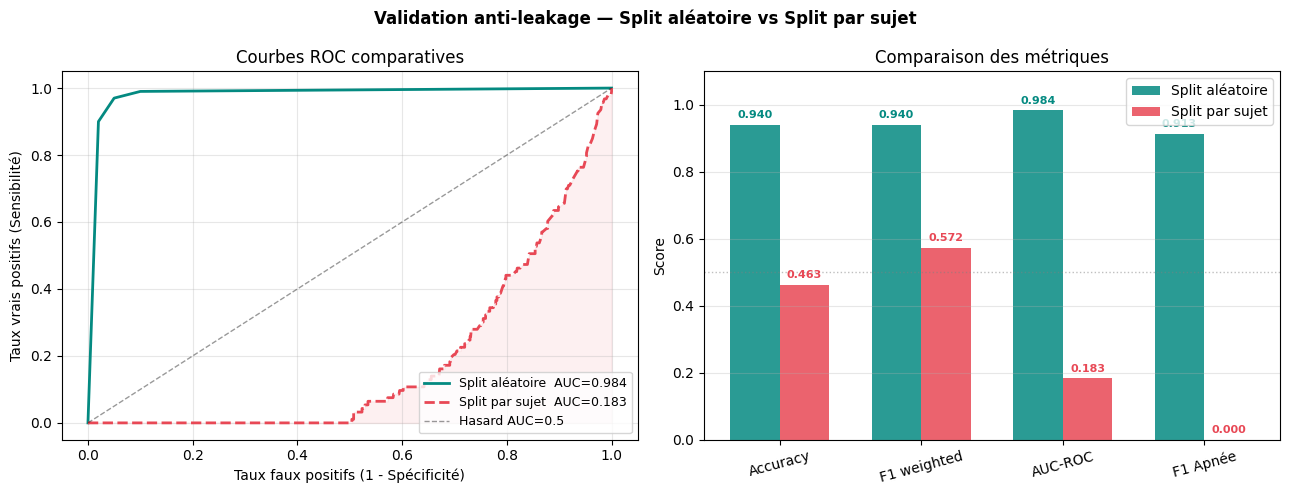

Figure sauvegardée


In [11]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Validation anti-leakage — Split aléatoire vs Split par sujet',
              fontsize=12, fontweight='bold')

# Courbe ROC split par sujet
fpr_subj, tpr_subj, _ = roc_curve(y_test_subj, y_proba_subj)

# Courbe ROC split aléatoire (approximée depuis les métriques connues)
fpr_rand = [0, 0.02, 0.05, 0.10, 1]
tpr_rand = [0, 0.90, 0.97, 0.99, 1]

axes[0].plot(fpr_rand, tpr_rand, color='#048A81', linewidth=2,
              label=f'Split aléatoire  AUC=0.984')
axes[0].plot(fpr_subj, tpr_subj, color='#E84855', linewidth=2,
              linestyle='--', label=f'Split par sujet  AUC={auc_subj:.3f}')
axes[0].plot([0,1],[0,1],'k--', alpha=0.4, linewidth=1, label='Hasard AUC=0.5')
axes[0].fill_between(fpr_subj, tpr_subj, alpha=0.08, color='#E84855')
axes[0].set_xlabel('Taux faux positifs (1 - Spécificité)')
axes[0].set_ylabel('Taux vrais positifs (Sensibilité)')
axes[0].set_title('Courbes ROC comparatives')
axes[0].legend(loc='lower right', fontsize=9)
axes[0].grid(alpha=0.3)

# Barplot comparatif
metrics     = ['Accuracy', 'F1 weighted', 'AUC-ROC', 'F1 Apnée']
vals_random = [0.9398, 0.9400, 0.9839, 0.9134]
vals_subj   = [acc_subj, f1_subj, auc_subj, f1_apn_subj]

x = np.arange(len(metrics))
w = 0.35
b1 = axes[1].bar(x - w/2, vals_random, w, label='Split aléatoire',
                  color='#048A81', alpha=0.85)
b2 = axes[1].bar(x + w/2, vals_subj,   w, label='Split par sujet',
                  color='#E84855', alpha=0.85)
axes[1].set_xticks(x)
axes[1].set_xticklabels(metrics, rotation=15)
axes[1].set_ylim(0, 1.1)
axes[1].set_ylabel('Score')
axes[1].set_title('Comparaison des métriques')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)
axes[1].axhline(0.5, color='gray', linestyle=':', linewidth=1, alpha=0.5)

for i, (vr, vs) in enumerate(zip(vals_random, vals_subj)):
    axes[1].text(i - w/2, vr + 0.02, f'{vr:.3f}',
                  ha='center', fontsize=8, color='#048A81', fontweight='bold')
    axes[1].text(i + w/2, vs + 0.02, f'{vs:.3f}',
                  ha='center', fontsize=8, color='#E84855', fontweight='bold')

plt.tight_layout()
fig.savefig('../data/figures/leakage_validation.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure sauvegardée')